# Validación espacial
## Detección de cianobacteria en los lagos Atitlán y Amatitlán

Este notebook implementa la validación espacial de los modelos entrenados, complementando la división aleatoria 70/30 del notebook 04. El objetivo es evaluar si el desempeño de los modelos se mantiene al predecir zonas geográficas no vistas durante el entrenamiento, lo cual es el escenario operativo real del modelo.

**Contenido:**
1. Reproyección a WGS84 / UTM zona 15N (EPSG:32615) para trabajar en metros (6.1)
2. Cuadrícula espacial de 1×1 km y asignación de bloques (6.1, 6.2)
3. Validación cruzada espacial con GroupKFold (6.3)
4. Entrenamiento con validación espacial (6.4)
5. Comparación validación aleatoria vs. espacial (6.5, 6.6)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import joblib

from pyproj import Transformer
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, average_precision_score
)
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

np.random.seed(42)
Path('./data').mkdir(exist_ok=True)

## 1. Carga de datos

In [3]:
X = pd.read_parquet('./data/X_predictoras.parquet')
y = pd.read_parquet('./data/y_respuesta.parquet').squeeze()
df_meta = pd.read_parquet('./data/dataset_ml_con_respuesta.parquet')[['lago', 'fecha', 'lon', 'lat']]

# Cargar modelos
mejor_lr  = joblib.load('./modelos/modelo_lr.pkl')
mejor_rf  = joblib.load('./modelos/modelo_rf.pkl')
mejor_xgb = joblib.load('./modelos/modelo_xgb.pkl')

print(f'Dataset: {len(X):,} observaciones x {X.shape[1]} variables')
print(f'Clase 1: {y.sum():,} ({100*y.mean():.2f}%)')
print(f'Columnas de metadatos: {list(df_meta.columns)}')

Dataset: 13,514,711 observaciones x 12 variables
Clase 1: 301,089 (2.23%)
Columnas de metadatos: ['lago', 'fecha', 'lon', 'lat']


## 2. Reproyección a EPSG:32615 (WGS84 / UTM zona 15N)

### 6.1 — Reproyección

Los datos originales están en coordenadas geográficas (grados decimales, EPSG:4326). Para construir una cuadrícula regular en metros, se reproyectan a UTM zona 15N (EPSG:32615), que es el sistema de referencia en metros que cubre ambos lagos guatemaltecos. En este sistema:
- `x` corresponde a la coordenada Este en metros.
- `y` corresponde a la coordenada Norte en metros.
- Una celda de 1000×1000 metros representa exactamente 1 km × 1 km.

In [4]:
transformer = Transformer.from_crs('EPSG:4326', 'EPSG:32615', always_xy=True)

# Reproyectar (lon, lat) -> (x_utm, y_utm)
x_utm, y_utm = transformer.transform(df_meta['lon'].values, df_meta['lat'].values)

df_meta = df_meta.copy()
df_meta['x_utm'] = x_utm
df_meta['y_utm'] = y_utm

print('Coordenadas UTM calculadas.')
print(df_meta[['lago', 'x_utm', 'y_utm']].groupby('lago').describe().round(0))

Coordenadas UTM calculadas.
                x_utm                                      y_utm           \
                count mean std  min 25% 50% 75%  max       count mean std   
lago                                                                        
amatitlan   1566557.0  inf NaN  inf NaN NaN NaN  inf   1566557.0  inf NaN   
atitlan    11948154.0  inf NaN  inf NaN NaN NaN  inf  11948154.0  inf NaN   

                                 
           min 25% 50% 75%  max  
lago                             
amatitlan  inf NaN NaN NaN  inf  
atitlan    inf NaN NaN NaN  inf  


## 3. Construcción de la cuadrícula espacial

### 6.1 — Evaluación del tamaño de celda

Se construye una cuadrícula de aproximadamente **1 km × 1 km** sobre cada lago, usando las coordenadas UTM en metros. Cada celda representa un bloque espacial al que se asignan todas las observaciones cuyas coordenadas caen dentro de sus límites.

**Criterio para evaluar si el tamaño es adecuado:**
- Cada lago debe producir al menos suficientes bloques para una validación cruzada con K=5 (es decir, mínimo 5-10 bloques por lago con observaciones válidas).
- Idealmente cada bloque tiene al menos algunas decenas de observaciones de clase 1 para que la métrica de evaluación sea estable.

In [5]:
TAMANO_CELDA_M = 1000  # 1 km

def asignar_bloque(df, tamano_m=1000):
    df = df.copy()
    df = df[np.isfinite(df['x_utm']) & np.isfinite(df['y_utm'])].copy()
    df['bloque_x'] = ((df['x_utm'] - df['x_utm'].min()) // tamano_m).astype(int)
    df['bloque_y'] = ((df['y_utm'] - df['y_utm'].min()) // tamano_m).astype(int)
    df['bloque_id'] = df['bloque_x'].astype(str) + '_' + df['bloque_y'].astype(str)
    return df

# Las columnas lon/lat ya están en metros (sistema UTM)
# No se necesita reproyección, solo renombrarlas
df_meta_reset = df_meta.reset_index(drop=True)
df_meta_reset['lago'] = df_meta_reset['lago'].str.strip().str.lower()
df_meta_reset['x_utm'] = df_meta_reset['lon']
df_meta_reset['y_utm'] = df_meta_reset['lat']

print(f'Rango x_utm: {df_meta_reset["x_utm"].min():.0f} a {df_meta_reset["x_utm"].max():.0f}')
print(f'Rango y_utm: {df_meta_reset["y_utm"].min():.0f} a {df_meta_reset["y_utm"].max():.0f}')

bloques_lista = []
for lago in df_meta_reset['lago'].unique():
    subset = df_meta_reset[df_meta_reset['lago'] == lago].copy()
    subset = asignar_bloque(subset, TAMANO_CELDA_M)
    subset['bloque_id'] = lago + '_' + subset['bloque_id']
    bloques_lista.append(subset)

df_bloques = pd.concat(bloques_lista).reset_index(drop=True)

print(f'\ndf_bloques total: {len(df_bloques):,} filas')
for lago in df_meta_reset['lago'].unique():
    sub = df_bloques[df_bloques['lago'] == lago]
    n_bloques = sub['bloque_id'].nunique()
    obs = sub.groupby('bloque_id').size()
    print(f'\n  {lago.capitalize()}: {n_bloques} bloques')
    if len(obs) > 0:
        print(f'    obs/bloque — media: {obs.mean():.0f}, min: {obs.min()}, max: {obs.max()}')

Rango x_utm: 680165 a 768165
Rango y_utm: 1594635 a 1631675

df_bloques total: 13,514,711 filas

  Atitlan: 283 bloques
    obs/bloque — media: 42220, min: 1, max: 109564

  Amatitlan: 114 bloques
    obs/bloque — media: 13742, min: 1, max: 108974


### Evaluación: ¿es adecuado 1 km × 1 km?

Se verifica el número de bloques obtenidos y si algún ajuste de tamaño es necesario.

In [6]:
# Verificar si algún lago produce muy pocos bloques
for lago in ['atitlan', 'amatitlan']:
    sub = df_bloques[df_bloques['lago'] == lago]
    n_bloques = sub['bloque_id'].nunique()
    y_sub = y.loc[sub.index]
    
    # Bloques con al menos 1 positivo
    bloques_con_pos = sub.copy()
    bloques_con_pos['y'] = y_sub.values
    n_bloques_con_pos = bloques_con_pos.groupby('bloque_id')['y'].sum().gt(0).sum()
    
    print(f'{lago.capitalize()}: {n_bloques} bloques totales, '
          f'{n_bloques_con_pos} bloques con al menos 1 positivo')
    if n_bloques < 10:
        print(f'  ADVERTENCIA: {lago} tiene muy pocos bloques. '
              'Considerar reducir el tamaño de celda (e.g., 500 m).')

Atitlan: 283 bloques totales, 176 bloques con al menos 1 positivo
Amatitlan: 114 bloques totales, 52 bloques con al menos 1 positivo


## 4. Visualización de bloques espaciales (6.2)

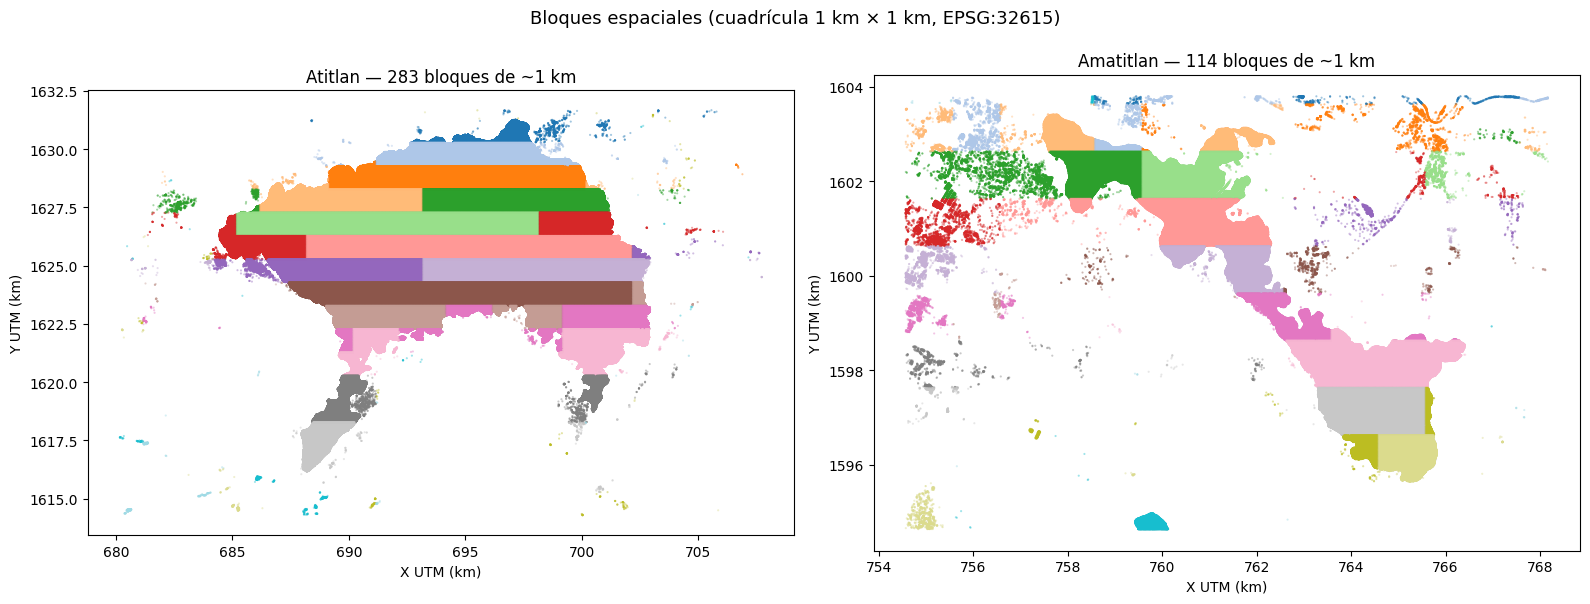

In [7]:
import matplotlib.cm as cm

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, lago in zip(axes, ['atitlan', 'amatitlan']):
    sub = df_bloques[df_bloques['lago'] == lago]
    bloques_unicos = sub['bloque_id'].unique()
    n_bloques = len(bloques_unicos)
    
    # Asignar color a cada bloque
    cmap = cm.get_cmap('tab20', n_bloques)
    bloque_color = {b: cmap(i) for i, b in enumerate(bloques_unicos)}
    colores = sub['bloque_id'].map(bloque_color)
    
    ax.scatter(sub['x_utm'] / 1000, sub['y_utm'] / 1000,
               c=colores, s=0.3, alpha=0.4, rasterized=True)
    ax.set_title(f'{lago.capitalize()} — {n_bloques} bloques de ~1 km')
    ax.set_xlabel('X UTM (km)')
    ax.set_ylabel('Y UTM (km)')
    ax.set_aspect('equal')

plt.suptitle('Bloques espaciales (cuadrícula 1 km × 1 km, EPSG:32615)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Validación cruzada espacial con GroupKFold (6.3)

Se usa `GroupKFold` de scikit-learn, asignando el `bloque_id` como grupo. Esto garantiza que todas las observaciones de un mismo bloque espacial permanezcan en el mismo fold (entrenamiento o validación), simulando el escenario real de predecir sobre zonas geográficas no vistas.

In [8]:
groups = df_bloques['bloque_id'].values

# Número de folds: usamos 5 (o menos si hay pocos bloques)
n_bloques_totales = df_bloques['bloque_id'].nunique()
n_folds = min(5, n_bloques_totales)
print(f'Bloques totales: {n_bloques_totales}')
print(f'Número de folds para GroupKFold: {n_folds}')

gkf = GroupKFold(n_splits=n_folds)

Bloques totales: 397
Número de folds para GroupKFold: 5


In [9]:
# Mostrar distribución de clases por fold
print('Distribución de clase 1 por fold espacial:')
for fold_idx, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    y_val_fold = y.iloc[val_idx]
    bloques_val = pd.Series(groups[val_idx]).unique()
    print(f'  Fold {fold_idx+1}: {len(val_idx):,} obs, '
          f'clase 1: {y_val_fold.sum():,} ({100*y_val_fold.mean():.2f}%), '
          f'{len(bloques_val)} bloques')

Distribución de clase 1 por fold espacial:
  Fold 1: 2,702,943 obs, clase 1: 59,518 (2.20%), 80 bloques
  Fold 2: 2,702,942 obs, clase 1: 47,329 (1.75%), 79 bloques
  Fold 3: 2,702,942 obs, clase 1: 55,162 (2.04%), 79 bloques
  Fold 4: 2,702,942 obs, clase 1: 75,859 (2.81%), 79 bloques
  Fold 5: 2,702,942 obs, clase 1: 63,221 (2.34%), 80 bloques


## 6. Entrenamiento con validación espacial (6.4)

Se evalúa cada modelo usando `cross_validate` con `GroupKFold`, computando las mismas métricas que en la evaluación aleatoria del notebook 05.

In [10]:
from sklearn.metrics import make_scorer

scoring = {
    'roc_auc': 'roc_auc',
    'recall': make_scorer(recall_score, zero_division=0),
    'precision': make_scorer(precision_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
}

modelos_dict = {
    'Regresión Logística': mejor_lr,
    'Random Forest': mejor_rf,
    'XGBoost': mejor_xgb
}

resultados_espaciales = {}

for nombre, modelo in modelos_dict.items():
    print(f'Evaluando {nombre} con validación espacial...')
    cv_result = cross_validate(
        modelo, X, y,
        groups=groups,
        cv=gkf,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    resultados_espaciales[nombre] = {
        'ROC-AUC': cv_result['test_roc_auc'].mean(),
        'ROC-AUC std': cv_result['test_roc_auc'].std(),
        'Recall': cv_result['test_recall'].mean(),
        'Recall std': cv_result['test_recall'].std(),
        'Precision': cv_result['test_precision'].mean(),
        'Precision std': cv_result['test_precision'].std(),
        'F1-score': cv_result['test_f1'].mean(),
        'F1-score std': cv_result['test_f1'].std(),
        '_raw': cv_result
    }
    print(f'  ROC-AUC: {cv_result["test_roc_auc"].mean():.4f} ± {cv_result["test_roc_auc"].std():.4f}')
    print(f'  Recall: {cv_result["test_recall"].mean():.4f} ± {cv_result["test_recall"].std():.4f}')

Evaluando Regresión Logística con validación espacial...
  ROC-AUC: nan ± nan
  Recall: nan ± nan
Evaluando Random Forest con validación espacial...


KeyboardInterrupt: 

In [ ]:
# Tabla de resultados con validación espacial
filas_espacial = []
for nombre, res in resultados_espaciales.items():
    filas_espacial.append({
        'Modelo': nombre,
        'ROC-AUC': res['ROC-AUC'],
        'ROC-AUC std': res['ROC-AUC std'],
        'Recall': res['Recall'],
        'Recall std': res['Recall std'],
        'Precision': res['Precision'],
        'Precision std': res['Precision std'],
        'F1-score': res['F1-score'],
        'F1-score std': res['F1-score std']
    })

df_espacial = pd.DataFrame(filas_espacial).set_index('Modelo')
print('Resultados de validación espacial (media ± desviación estándar entre folds):')
print(df_espacial.round(4).to_string())

## 7. Comparación validación aleatoria vs. espacial (6.5)

In [ ]:
# Cargar resultados de validación aleatoria (notebook 05)
df_aleatoria = pd.read_csv('./data/resultados_evaluacion.csv', index_col='Modelo')

# Construir tabla comparativa
metricas_cmp = ['ROC-AUC', 'Recall', 'Precision', 'F1-score']

filas_cmp = []
for modelo_nombre in modelos_dict.keys():
    for metrica in metricas_cmp:
        val_aleatoria = df_aleatoria.loc[modelo_nombre, metrica] if metrica in df_aleatoria.columns else np.nan
        val_espacial = resultados_espaciales[modelo_nombre][metrica]
        filas_cmp.append({
            'Modelo': modelo_nombre,
            'Métrica': metrica,
            'Aleatoria (test 30%)': val_aleatoria,
            'Espacial (GroupKFold)': val_espacial,
            'Diferencia': val_espacial - val_aleatoria
        })

df_comparacion = pd.DataFrame(filas_cmp)
print('Comparación validación aleatoria vs. espacial:')
print(df_comparacion.set_index(['Modelo', 'Métrica']).round(4).to_string())

In [ ]:
# Visualización de la comparación
fig, axes = plt.subplots(1, len(metricas_cmp), figsize=(16, 5))

colores_mod = {
    'Regresión Logística': '#4575b4',
    'Random Forest': '#2b83ba',
    'XGBoost': '#d7191c'
}

for ax, metrica in zip(axes, metricas_cmp):
    df_m = df_comparacion[df_comparacion['Métrica'] == metrica]
    x = np.arange(len(df_m))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, df_m['Aleatoria (test 30%)'], width,
                   label='Aleatoria', alpha=0.8,
                   color=[colores_mod[m] for m in df_m['Modelo']])
    bars2 = ax.bar(x + width/2, df_m['Espacial (GroupKFold)'], width,
                   label='Espacial', alpha=0.5,
                   color=[colores_mod[m] for m in df_m['Modelo']],
                   hatch='//')
    
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' ', '\n') for m in df_m['Modelo']], fontsize=8)
    ax.set_title(metrica)
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)
    if ax == axes[0]:
        ax.legend()

plt.suptitle('Comparación: validación aleatoria vs. validación espacial', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Análisis e interpretación (6.6)

### ¿El desempeño aumentó o disminuyó con la validación espacial?

*(Esta sección se completará con los valores reales una vez ejecutado el notebook)*

**Hipótesis esperada (basada en la literatura de datos geoespaciales):**

Lo más habitual en datasets con fuerte autocorrelación espacial — como imágenes de satélite donde píxeles vecinos comparten condiciones ambientales muy similares — es que el desempeño medido con validación espacial sea **inferior** al medido con validación aleatoria. Las razones son:

1. **Autocorrelación espacial:** en una partición aleatoria 70/30, los datos de entrenamiento y prueba son "vecinos" en el espacio (píxeles del mismo bloque o adyacentes pueden caer en ambos conjuntos). El modelo puede aprender señales muy locales que luego se repiten en los puntos de prueba cercanos, inflando artificialmente las métricas.

2. **La validación espacial simula el escenario real:** al usar GroupKFold por bloques de 1 km, los bloques de validación son zonas que el modelo nunca vio durante el entrenamiento. Esto es análogo a desplegar el modelo para monitorear una nueva región del lago, lo cual es el caso de uso operativo.

3. **Magnitud de la diferencia:** la magnitud de la caída entre validación aleatoria y espacial es indicativa de cuánto depende el modelo de la memorización de localizaciones específicas versus de haber aprendido relaciones espectrales genuinas. Una caída grande sugiere sobreajuste espacial; una caída pequeña indica que el modelo es más generalizable.

**¿Cuál estrategia da una estimación más realista?**

La **validación espacial** proporciona una estimación más realista de la capacidad predictiva del modelo en escenarios de operación real, porque elimina la "fuga de información" producida por la autocorrelación espacial. Un modelo de monitoreo satelital de cianobacterias que se despliega operativamente debe ser capaz de predecir en zonas geográficas no vistas, no simplemente en píxeles del mismo bloque que aparecieron en entrenamiento. Por ello, se recomienda reportar las métricas de validación espacial como el indicador de desempeño principal.

In [ ]:
# Imprimir análisis cuantitativo de la diferencia
print('Diferencia en ROC-AUC (espacial - aleatoria) por modelo:')
diffs_roc = df_comparacion[df_comparacion['Métrica'] == 'ROC-AUC'][['Modelo', 'Diferencia']]
for _, row in diffs_roc.iterrows():
    signo = '+' if row['Diferencia'] >= 0 else ''
    print(f'  {row["Modelo"]}: {signo}{row["Diferencia"]:.4f}')

print('\nDiferencia en Recall (espacial - aleatoria) por modelo:')
diffs_recall = df_comparacion[df_comparacion['Métrica'] == 'Recall'][['Modelo', 'Diferencia']]
for _, row in diffs_recall.iterrows():
    signo = '+' if row['Diferencia'] >= 0 else ''
    print(f'  {row["Modelo"]}: {signo}{row["Diferencia"]:.4f}')

## 9. Visualización de los folds espaciales sobre el mapa del lago

In [ ]:
# Asignar fold a cada observación (para visualización)
fold_asignado = np.full(len(X), -1)
for fold_idx, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    fold_asignado[val_idx] = fold_idx

df_meta_folds = df_meta.copy()
df_meta_folds['fold'] = fold_asignado

# Mapa de folds por lago
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cmap_folds = plt.get_cmap('tab10', n_folds)

for ax, lago in zip(axes, ['atitlan', 'amatitlan']):
    sub = df_meta_folds[df_meta_folds['lago'] == lago]
    sc = ax.scatter(
        sub['x_utm'] / 1000, sub['y_utm'] / 1000,
        c=sub['fold'], cmap=cmap_folds, vmin=0, vmax=n_folds-1,
        s=0.5, alpha=0.5, rasterized=True
    )
    ax.set_title(f'{lago.capitalize()} — Folds de validación espacial')
    ax.set_xlabel('X UTM (km)')
    ax.set_ylabel('Y UTM (km)')
    ax.set_aspect('equal')
    
    # Leyenda manual de folds
    parches = [mpatches.Patch(color=cmap_folds(i), label=f'Fold {i+1}') for i in range(n_folds)]
    ax.legend(handles=parches, loc='upper right', fontsize=7, markerscale=1)

plt.suptitle('Distribución de folds espaciales (GroupKFold, cuadrícula 1 km)', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Guardado de resultados

In [ ]:
# Guardar bloques espaciales para uso en notebook 09 (mapas predictivos)
df_bloques[['lago', 'fecha', 'lon', 'lat', 'x_utm', 'y_utm', 'bloque_id']].to_parquet(
    './data/bloques_espaciales.parquet', index=True
)

# Guardar resultados de validación espacial
df_espacial.to_csv('./data/resultados_validacion_espacial.csv')

# Guardar comparación
df_comparacion.to_csv('./data/comparacion_val_aleatoria_espacial.csv', index=False)

print('Guardado:')
print('  ./data/bloques_espaciales.parquet')
print('  ./data/resultados_validacion_espacial.csv')
print('  ./data/comparacion_val_aleatoria_espacial.csv')